# Assigning Simulated FRBs to Host Galaxies

This notebook demonstrates how to use the `astropath.simulations.assign_host` module to assign simulated FRBs to host galaxies from a catalog.

The assignment process:
1. Matches FRBs to galaxies by **apparent magnitude** (brighter FRBs → brighter galaxies)
2. Randomly places FRBs within their host galaxy
3. Applies realistic **localization errors** to create observed coordinates

**Output includes:**
- Observed FRB coordinates (with localization error)
- True FRB coordinates (within the galaxy)
- Host galaxy properties (ID, magnitude, size)
- Offset statistics (galaxy offset, localization error)

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from pathlib import Path
from matplotlib.patches import Ellipse


# Set up plotting style
plt.rcParams['figure.figsize'] = (10, 6)
plt.rcParams['font.size'] = 12

In [2]:
from astropath.simulations import generate_frbs, assign_frbs_to_hosts
from astropath.simulations.generate_frbs import load_chime_cat1_DMeg

/home/xavier/Projects/FRB/FRB/frb/halos/hmf.py:51: UserWarning: hmf_emulator not imported.  Hope you are not intending to use the hmf.py module..
  warnings.warn("hmf_emulator not imported.  Hope you are not intending to use the hmf.py module..")


## Step 1: Generate FRB Population

First, we generate a population of FRBs using `generate_frbs()`. This gives us FRBs with realistic DM, redshift, and host galaxy magnitude distributions.

In [4]:
# Generate 500 CHIME FRBs following the Cat1 DM distribution
n_frbs = 1000
seed = 42

#frbs = generate_frbs(n_frbs, 'CHIME', seed=seed)
DMeg = load_chime_cat1_DMeg()
frbs = generate_frbs(n_frbs, 'CHIME', seed=seed, 
        dm_catalog=DMeg, dm_range=(0., 3000.))

print(f"Generated {len(frbs)} FRBs")
print(f"\nFRB properties:")
print(f"  DM range:  {frbs['DMeg'].min():.0f} - {frbs['DMeg'].max():.0f} pc/cm³")
print(f"  z range:   {frbs['z'].min():.3f} - {frbs['z'].max():.3f}")
print(f"  M_r range: {frbs['M_r'].min():.2f} - {frbs['M_r'].max():.2f}")
print(f"  m_r range: {frbs['m_r'].min():.2f} - {frbs['m_r'].max():.2f}")

frbs.head()

Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/CHIME_pzdm.npz
Sampling DM values
Sampling redshifts
Sampling host galaxy absolute magnitudes
Generated 1000 FRBs

FRB properties:
  DM range:  4 - 2421 pc/cm³
  z range:   0.010 - 2.156
  M_r range: -24.13 - -15.72
  m_r range: 10.90 - 28.43


,DMeg,z,M_r,m_r
0,332.544726,0.129937,-21.159247,17.838785
1,1321.835444,1.159081,-21.225508,23.329408
2,702.774725,0.896607,-17.680340,26.187733
3,535.990017,0.598077,-21.213956,21.580659
4,165.368080,0.195489,-21.113479,18.857862


## Step 2: Load Galaxy Catalog

We'll use a real galaxy catalog if available (combined HSC/DECaLs/HECATE), otherwise create a mock catalog.

The catalog must have these columns:
- `ra`, `dec`: Coordinates (degrees)
- `mag_best`: Apparent r-band magnitude
- `half_light`: Half-light radius (arcsec)
- `ID`: Unique identifier

In [5]:
def create_mock_galaxy_catalog(n_galaxies=10000, seed=42):
    """
    Create a mock galaxy catalog for demonstration.
    This is used as a fallback if real catalog is not available.
    """
    np.random.seed(seed)
    
    # Create galaxies in a 2x2 degree field
    ra = np.random.uniform(150.0, 152.0, n_galaxies)
    dec = np.random.uniform(2.0, 4.0, n_galaxies)
    
    # Magnitude distribution (peaks around m_r ~ 21-22)
    mag_best = np.random.beta(a=2, b=5, size=n_galaxies) * 8 + 18
    mag_best = np.clip(mag_best, 18., 26.)
    
    # Half-light radii (log-normal distribution)
    half_light = np.random.lognormal(mean=np.log(0.5), sigma=0.5, size=n_galaxies)
    half_light = np.clip(half_light, 0.1, 3.0)
    
    df = pd.DataFrame({
        'ra': ra,
        'dec': dec,
        'mag_best': mag_best,
        'half_light': half_light,
        'ID': np.arange(n_galaxies)
    })
    
    return df


def load_galaxy_catalog(seed=42):
    """
    Load galaxy catalog - tries real catalog first, falls back to mock.
    
    Real catalog: $FRB_APATH/combined_HSC_DECaLs_HECATE_galaxies_hecatecut.parquet
    """
    # Try to load real catalog
    frb_apath = os.environ.get('FRB_APATH')
    
    if frb_apath is not None:
        catalog_path = Path(frb_apath) / 'combined_HSC_DECaLs_HECATE_galaxies_hecatecut.parquet'
        
        if catalog_path.exists():
            print(f"Loading real galaxy catalog from:")
            print(f"  {catalog_path}")
            galaxies = pd.read_parquet(catalog_path)
            
            # Verify required columns
            required_cols = ['ra', 'dec', 'mag_best', 'half_light', 'ID']
            if all(col in galaxies.columns for col in required_cols):
                print(f"  ✓ Loaded {len(galaxies):,} galaxies from real catalog")
                return galaxies, True
            else:
                print(f"  ⚠ Missing required columns, falling back to mock catalog")
    
    # Fall back to mock catalog
    print("Creating mock galaxy catalog...")
    print("  (Set $FRB_APATH to use real HSC/DECaLs/HECATE catalog)")
    galaxies = create_mock_galaxy_catalog(n_galaxies=10000, seed=seed)
    print(f"  Created {len(galaxies):,} mock galaxies")
    return galaxies, False


# Load catalog (real or mock)
galaxies, is_real = load_galaxy_catalog(seed=42)

print(f"\nGalaxy catalog properties:")
print(f"  Type:       {'Real (HSC/DECaLs/HECATE)' if is_real else 'Mock'}")
print(f"  N_galaxies: {len(galaxies):,}")
print(f"  RA range:   {galaxies['ra'].min():.2f} - {galaxies['ra'].max():.2f} deg")
print(f"  Dec range:  {galaxies['dec'].min():.2f} - {galaxies['dec'].max():.2f} deg")
print(f"  Mag range:  {galaxies['mag_best'].min():.2f} - {galaxies['mag_best'].max():.2f}")
print(f"  Size range: {galaxies['half_light'].min():.2f} - {galaxies['half_light'].max():.2f} arcsec")

galaxies.head()

Loading real galaxy catalog from:
  /home/xavier/Projects/FRB/data/Catalogs/combined_HSC_DECaLs_HECATE_galaxies_hecatecut.parquet
  ✓ Loaded 2,297,005 galaxies from real catalog

Galaxy catalog properties:
  Type:       Real (HSC/DECaLs/HECATE)
  N_galaxies: 2,297,005
  RA range:   0.17 - 359.92 deg
  Dec range:  -22.67 - 79.20 deg
  Mag range:  9.75 - 28.00
  Size range: 0.00 - 111.73 arcsec


,DECaL_r,DECaL_ID,ra,dec,gaia_pointsource,shapedev_r,shapeexp_r,type,mag,ang_size,...,logSFR_GSW,logM_GSW,MIN_SNR,METAL,FLAG_METAL,CLASS_SP,AGN_S17,AGN_HEC,mag_best,half_light
0,20.342830,8.796112e+15,33.714628,-7.532246,0.0,0.794133,0.000000,DEV,20.342830,0.794133,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,20.342830,0.794133
1,21.302168,8.796112e+15,33.543950,-7.531977,0.0,0.000000,1.474610,EXP,21.302168,1.474610,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,21.302168,1.474610
2,18.706774,8.796112e+15,33.731347,-7.531399,0.0,0.000000,5.484947,EXP,18.706774,5.484947,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,18.706774,5.484947
3,21.775625,8.796112e+15,33.730953,-7.533122,0.0,0.000000,1.568451,EXP,21.775625,1.568451,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,21.775625,1.568451
4,21.368427,8.796112e+15,33.731264,-7.529217,0.0,0.000000,4.333760,EXP,21.368427,4.333760,...,NaN,NaN,NaN,NaN,NaN,NaN,None,None,21.368427,4.333760


### Visualize Galaxy Catalog

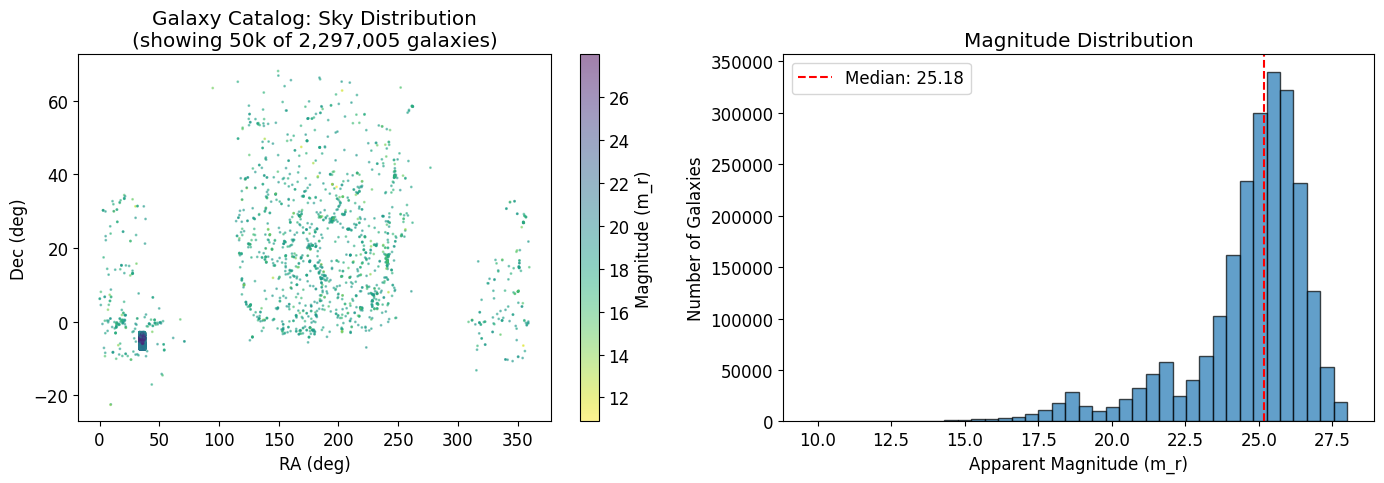

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sky distribution
ax = axes[0]

# For real catalog, sample subset for visualization (too many points)
if len(galaxies) > 50000:
    plot_galaxies = galaxies.sample(n=50000, random_state=42)
    plot_title = f'Galaxy Catalog: Sky Distribution\n(showing 50k of {len(galaxies):,} galaxies)'
else:
    plot_galaxies = galaxies
    plot_title = 'Galaxy Catalog: Sky Distribution'

scatter = ax.scatter(plot_galaxies['ra'], plot_galaxies['dec'], 
                     c=plot_galaxies['mag_best'], s=1, alpha=0.5, cmap='viridis_r')
ax.set_xlabel('RA (deg)')
ax.set_ylabel('Dec (deg)')
ax.set_title(plot_title)
plt.colorbar(scatter, ax=ax, label='Magnitude (m_r)')

# Magnitude distribution
ax = axes[1]
ax.hist(galaxies['mag_best'], bins=40, alpha=0.7, edgecolor='black')
ax.set_xlabel('Apparent Magnitude (m_r)')
ax.set_ylabel('Number of Galaxies')
ax.set_title('Magnitude Distribution')
ax.axvline(galaxies['mag_best'].median(), color='red', linestyle='--', 
           label=f"Median: {galaxies['mag_best'].median():.2f}")
ax.legend()

plt.tight_layout()
plt.show()

## Step 3: Assign FRBs to Host Galaxies

Now we assign FRBs to host galaxies. The key parameter is the **localization error ellipse** `(a, b, PA)`:
- `a`: Semi-major axis (arcsec)
- `b`: Semi-minor axis (arcsec)  
- `PA`: Position angle (degrees, East of North)

We'll use CHIME-like localization: ~0.5" × 0.3" ellipse.

In [7]:
# CHIME-like localization
localization = (0.5, 0.3, 45.)  # (a, b, PA) in arcsec, arcsec, degrees

print(f"Localization error ellipse:")
print(f"  Semi-major axis (a): {localization[0]}\"")
print(f"  Semi-minor axis (b): {localization[1]}\"")
print(f"  Position angle:      {localization[2]}°")
print()

# Assign FRBs to hosts
assignments = assign_frbs_to_hosts(
    frb_df=frbs,
    galaxy_catalog=galaxies,
    localization=localization,
    scale=0.5, #trim_catalog=60*units.arcmin,
    #mag_range=(17., 28.),  # Only assign FRBs with hosts in this mag range
    seed=seed
)

print(f"\nSuccessfully assigned {len(assignments)} FRBs to hosts")
print(f"(Filtered from {len(frbs)} based on magnitude range)")

assignments.head(10)

Localization error ellipse:
  Semi-major axis (a): 0.5"
  Semi-minor axis (b): 0.3"
  Position angle:      45.0°

Assigning 1000 FRBs to hosts (filtered from 1000)
Iteration 1: 1000 FRBs remaining
  Brightest unassigned FRB: m_r = 10.90 deg
  Max magnitude separation: 0.4349 deg deg
Iteration 2: 9 FRBs remaining
  Brightest unassigned FRB: m_r = 13.23 deg
Iteration 3: 3 FRBs remaining
  Brightest unassigned FRB: m_r = 28.17 deg
Iteration 4: 2 FRBs remaining
  Brightest unassigned FRB: m_r = 28.40 deg
Iteration 5: 1 FRBs remaining
  Brightest unassigned FRB: m_r = 28.40 deg
Assignment complete after 5 iterations
Generating FRB positions within galaxies...
Applying localization error...

Successfully assigned 1000 FRBs to hosts
(Filtered from 1000 based on magnitude range)


,ra,dec,true_ra,true_dec,gal_ID,gal_off,mag,half_light,loc_off,FRB_ID,a,b,PA
0,9.756662,-9.000325,9.756856,-9.000296,8796111290238957,3.196654,17.838830,13.624000,0.698880,0,0.5,0.3,45.0
1,35.636019,-3.364875,35.635951,-3.364826,38553851241978368,0.600715,23.329409,0.399130,0.300721,1,0.5,0.3,45.0
2,36.079067,-5.963041,36.079280,-5.962921,36429465928098630,0.193522,26.187733,0.293940,0.875139,2,0.5,0.3,45.0
3,37.747168,-4.744954,37.747133,-4.745082,8796112891154284,0.157167,21.580660,0.344308,0.476924,3,0.5,0.3,45.0
4,38.121684,-6.436465,38.121539,-6.436492,8796112233371896,0.076194,18.857872,0.898384,0.527688,4,0.5,0.3,45.0
5,33.814341,-4.719656,33.814420,-4.719800,8796112890106656,0.029800,20.773570,0.351424,0.588104,5,0.5,0.3,45.0
6,36.047698,-4.795770,36.047899,-4.795749,8796112890694034,0.082121,17.229322,2.744759,0.723296,6,0.5,0.3,45.0
7,35.979404,-4.878330,35.979269,-4.878467,37489386547338090,0.316137,26.088284,0.314372,0.690091,7,0.5,0.3,45.0
8,345.848447,13.920615,345.848223,13.920432,8796119999513484,0.634412,18.474115,1.380533,1.022398,8,0.5,0.3,45.0
9,36.359658,-5.665620,36.359614,-5.665606,37488957050604708,0.277805,22.478523,0.451257,0.162957,9,0.5,0.3,45.0


## Step 4: Analyze Results

### Offset Statistics

In [8]:
print("Offset Statistics")
print("=" * 60)

print("\nGalaxy Offset (FRB position from galaxy center):")
print(f"  Mean:   {assignments['gal_off'].mean():.3f}\"")
print(f"  Median: {assignments['gal_off'].median():.3f}\"")
print(f"  Std:    {assignments['gal_off'].std():.3f}\"")
print(f"  Max:    {assignments['gal_off'].max():.3f}\"")

print("\nLocalization Offset (observed - true position):")
print(f"  Mean:   {assignments['loc_off'].mean():.3f}\"")
print(f"  Median: {assignments['loc_off'].median():.3f}\"")
print(f"  Std:    {assignments['loc_off'].std():.3f}\"")
print(f"  Max:    {assignments['loc_off'].max():.3f}\"")

print("\nHost Galaxy Magnitudes:")
print(f"  Mean:   {assignments['mag'].mean():.2f}")
print(f"  Median: {assignments['mag'].median():.2f}")
print(f"  Range:  {assignments['mag'].min():.2f} - {assignments['mag'].max():.2f}")

Offset Statistics

Galaxy Offset (FRB position from galaxy center):
  Mean:   0.576"
  Median: 0.278"
  Std:    2.466"
  Max:    73.954"

Localization Offset (observed - true position):
  Mean:   0.487"
  Median: 0.443"
  Std:    0.268"
  Max:    1.413"

Host Galaxy Magnitudes:
  Mean:   20.67
  Median: 20.85
  Range:  10.88 - 28.00


### Offset Distributions

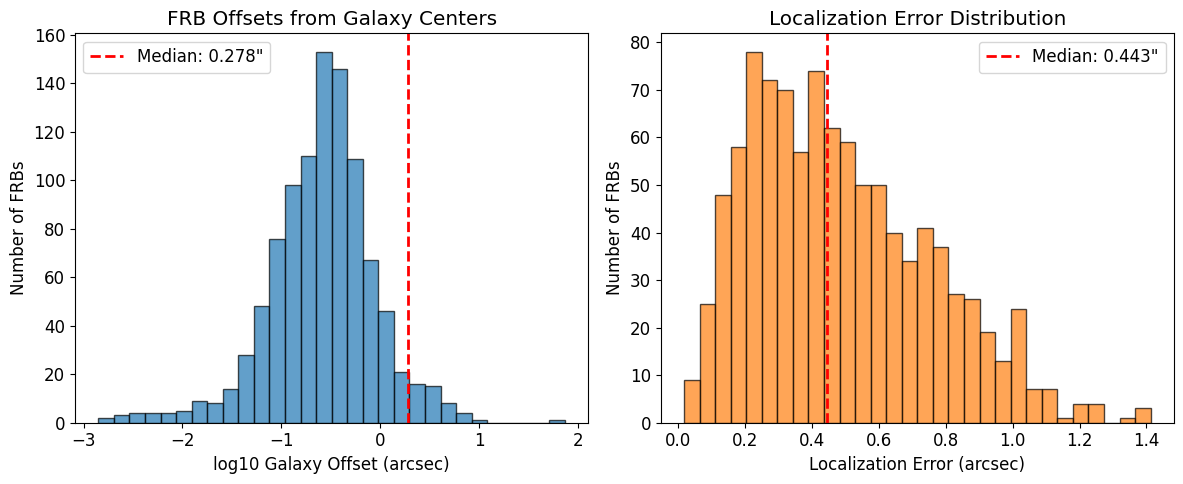

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Galaxy offsets
ax = axes[0]
ax.hist(np.log10(assignments['gal_off']), bins=30, alpha=0.7, edgecolor='black', color='#1f77b4')
ax.axvline(assignments['gal_off'].median(), color='red', linestyle='--', linewidth=2,
           label=f"Median: {assignments['gal_off'].median():.3f}\"")
ax.set_xlabel('log10 Galaxy Offset (arcsec)')
ax.set_ylabel('Number of FRBs')
#ax.set_xscale('log')
ax.set_title('FRB Offsets from Galaxy Centers')
ax.legend()

# Localization errors
ax = axes[1]
ax.hist(assignments['loc_off'], bins=30, alpha=0.7, edgecolor='black', color='#ff7f0e')
ax.axvline(assignments['loc_off'].median(), color='red', linestyle='--', linewidth=2,
           label=f"Median: {assignments['loc_off'].median():.3f}\"")
ax.set_xlabel('Localization Error (arcsec)')
ax.set_ylabel('Number of FRBs')
ax.set_title('Localization Error Distribution')
ax.legend()

plt.tight_layout()
plt.show()

### Host Galaxy Properties

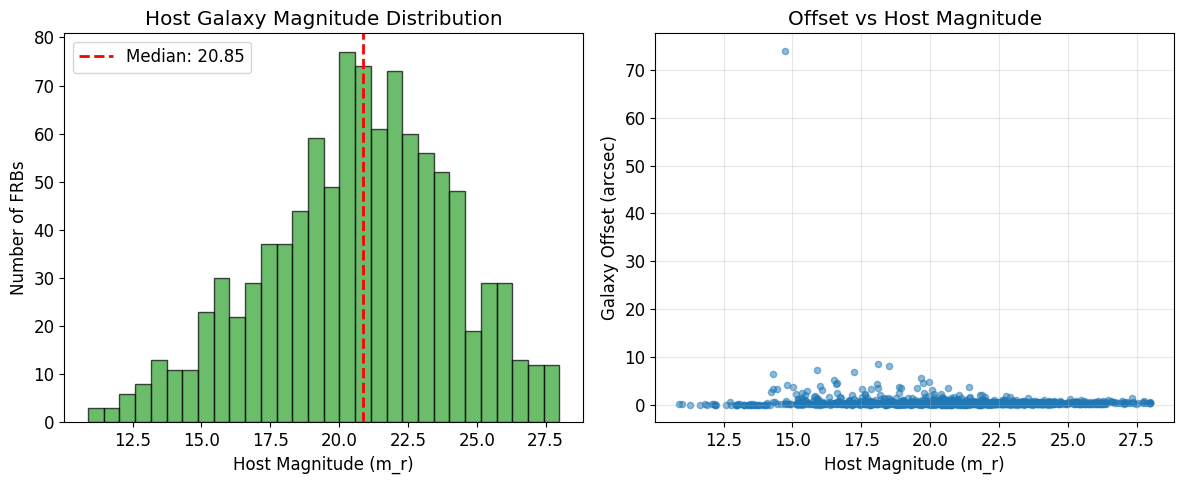

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Host magnitude distribution
ax = axes[0]
ax.hist(assignments['mag'], bins=30, alpha=0.7, edgecolor='black', color='#2ca02c')
ax.axvline(assignments['mag'].median(), color='red', linestyle='--', linewidth=2,
           label=f"Median: {assignments['mag'].median():.2f}")
ax.set_xlabel('Host Magnitude (m_r)')
ax.set_ylabel('Number of FRBs')
ax.set_title('Host Galaxy Magnitude Distribution')
ax.legend()

# Offset vs magnitude
ax = axes[1]
ax.scatter(assignments['mag'], assignments['gal_off'], alpha=0.5, s=20, color='#1f77b4')
ax.set_xlabel('Host Magnitude (m_r)')
ax.set_ylabel('Galaxy Offset (arcsec)')
ax.set_title('Offset vs Host Magnitude')
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## Step 5: Visualize FRB-Host Associations

Let's visualize a few example FRB-host associations, showing:
- Galaxy center (blue)
- True FRB position in galaxy (green)
- Observed FRB position with localization error (red)
- Localization error ellipse

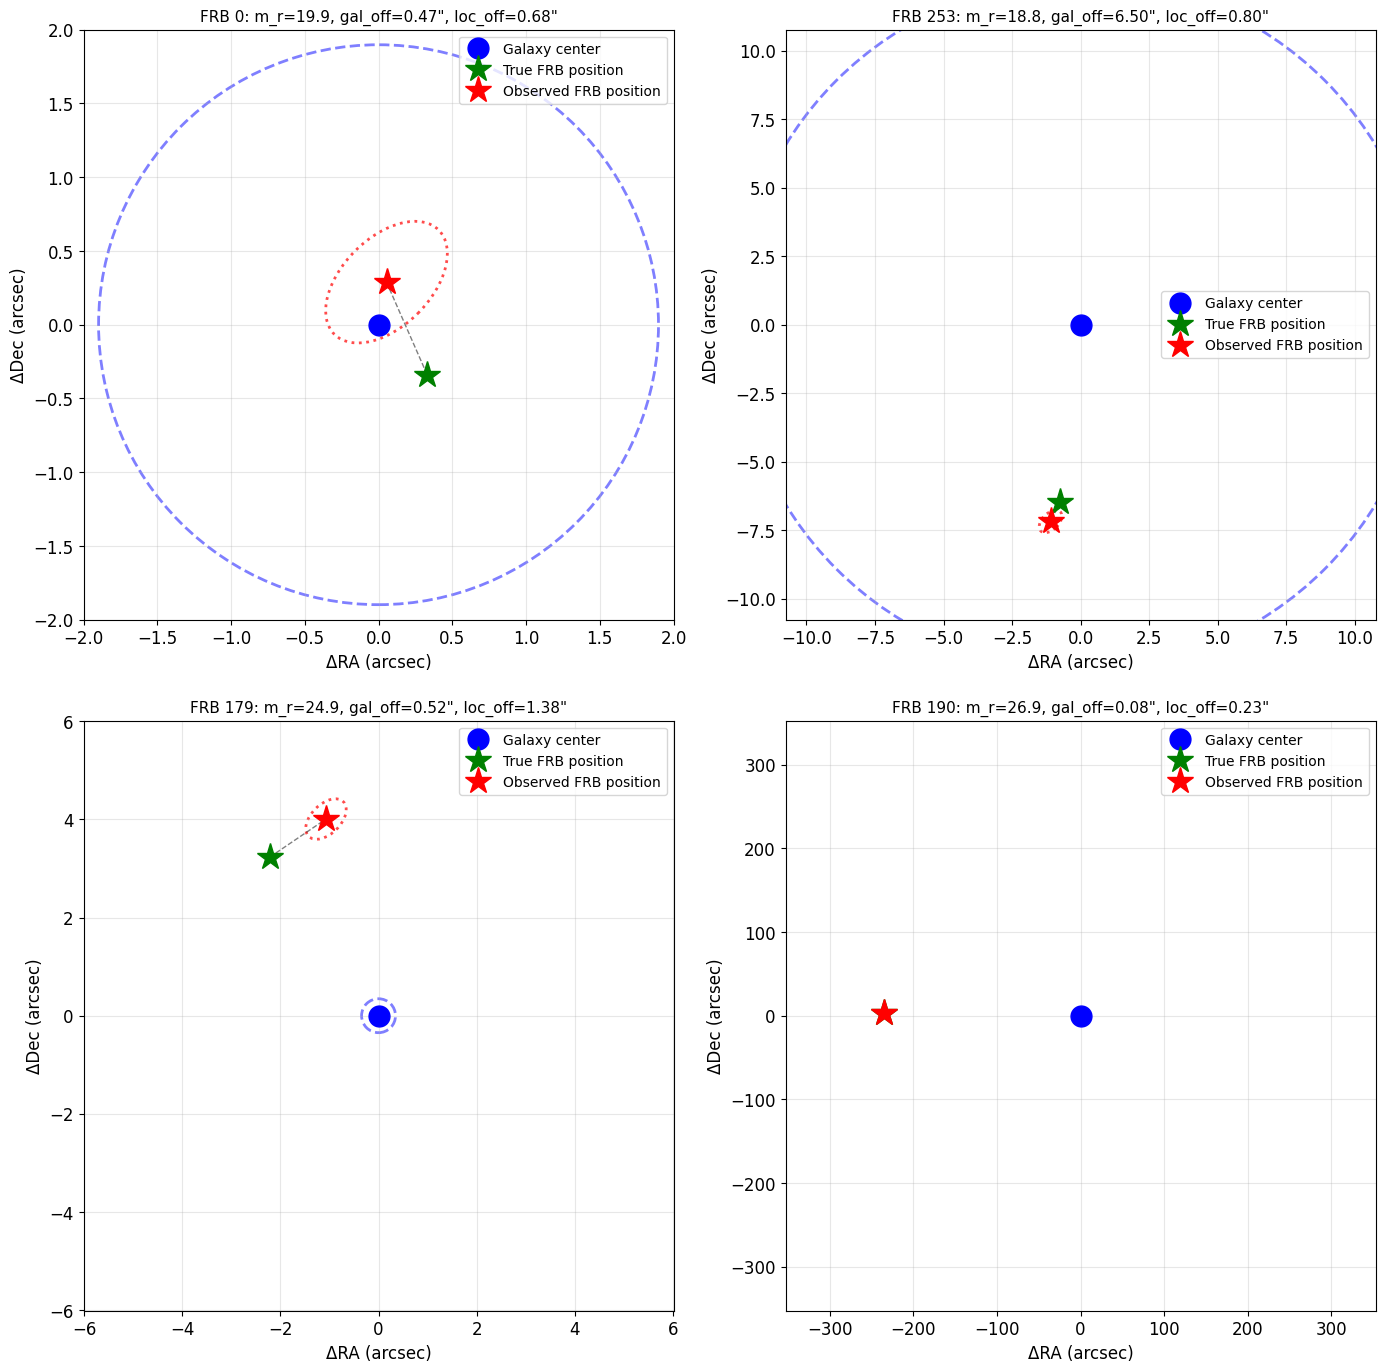

In [10]:
def plot_frb_host_association(assignments, galaxies, idx, ax=None):
    """
    Plot a single FRB-host association showing galaxy, true position, 
    observed position, and localization ellipse.
    """
    if ax is None:
        fig, ax = plt.subplots(figsize=(8, 8))
    
    # Get FRB and galaxy data
    frb = assignments.iloc[idx]
    galaxy = galaxies[galaxies['ID'] == frb['gal_ID']].iloc[0]
    
    # Convert to offset from galaxy center (in arcsec)
    # Approximate: 1 deg ≈ 3600 arcsec
    true_ra_off = (frb['true_ra'] - galaxy['ra']) * 3600 * np.cos(np.radians(galaxy['dec']))
    true_dec_off = (frb['true_dec'] - galaxy['dec']) * 3600
    
    obs_ra_off = (frb['ra'] - galaxy['ra']) * 3600 * np.cos(np.radians(galaxy['dec']))
    obs_dec_off = (frb['dec'] - galaxy['dec']) * 3600
    
    # Plot galaxy center
    ax.plot(0, 0, 'o', markersize=15, color='blue', label='Galaxy center', zorder=3)
    
    # Plot galaxy half-light circle
    circle = plt.Circle((0, 0), galaxy['half_light'], color='blue', 
                        fill=False, linestyle='--', linewidth=2, alpha=0.5)
    ax.add_patch(circle)
    
    # Plot true FRB position
    ax.plot(true_ra_off, true_dec_off, '*', markersize=20, color='green', 
            label='True FRB position', zorder=4)
    
    # Plot observed FRB position
    ax.plot(obs_ra_off, obs_dec_off, '*', markersize=20, color='red', 
            label='Observed FRB position', zorder=5)
    
    # Plot localization error ellipse
    ellipse = Ellipse((obs_ra_off, obs_dec_off), 
                      width=2*frb['a'], height=2*frb['b'], 
                      angle=frb['PA'],
                      edgecolor='red', facecolor='none', 
                      linewidth=2, linestyle=':', alpha=0.7)
    ax.add_patch(ellipse)
    
    # Connect true and observed positions
    ax.plot([true_ra_off, obs_ra_off], [true_dec_off, obs_dec_off], 
            'k--', linewidth=1, alpha=0.5, zorder=2)
    
    # Set limits based on max offset
    max_offset = max(abs(true_ra_off), abs(true_dec_off), 
                     abs(obs_ra_off), abs(obs_dec_off)) * 1.5
    max_offset = max(max_offset, 2.0)  # At least 2 arcsec
    ax.set_xlim(-max_offset, max_offset)
    ax.set_ylim(-max_offset, max_offset)
    
    ax.set_xlabel('ΔRA (arcsec)', fontsize=12)
    ax.set_ylabel('ΔDec (arcsec)', fontsize=12)
    ax.set_title(f'FRB {idx}: m_r={frb["mag"]:.1f}, '
                 f'gal_off={frb["gal_off"]:.2f}", loc_off={frb["loc_off"]:.2f}"',
                 fontsize=11)
    ax.legend(fontsize=10)
    ax.grid(alpha=0.3)
    ax.set_aspect('equal')
    
    return ax

# Plot 4 example associations
fig, axes = plt.subplots(2, 2, figsize=(14, 14))
axes = axes.flatten()

# Select FRBs with different characteristics
example_indices = [
    0,  # First FRB
    np.argmax(assignments['gal_off'].values),  # Largest galaxy offset
    np.argmax(assignments['loc_off'].values),  # Largest localization error
    len(assignments) // 2  # Middle FRB
]

for i, idx in enumerate(example_indices):
    plot_frb_host_association(assignments, galaxies, idx, ax=axes[i])

plt.tight_layout()
plt.show()

## Step 6: Comparing Different Localizations

Different surveys have different localization capabilities. Let's compare CHIME, DSA, and ASKAP-like localizations.

In [11]:
# Generate FRBs for different surveys
frbs_surveys = {
    'CHIME': generate_frbs(300, 'CHIME', seed=42),
    'DSA': generate_frbs(300, 'DSA', seed=42),
    'ASKAP': generate_frbs(300, 'ASKAP', seed=42)
}

# Define survey-specific localizations
localizations = {
    'CHIME': (0.5, 0.3, 45.),    # ~0.5" × 0.3" ellipse
    'DSA': (0.1, 0.1, 0.),        # ~0.1" circular (high precision)
    'ASKAP': (2.0, 1.0, 30.)      # ~2" × 1" ellipse (larger)
}

# Assign FRBs to hosts for each survey
assignments_surveys = {}
for survey in ['CHIME', 'DSA', 'ASKAP']:
    print(f"\nAssigning {survey} FRBs...")
    assignments_surveys[survey] = assign_frbs_to_hosts(
        frb_df=frbs_surveys[survey],
        galaxy_catalog=galaxies,
        localization=localizations[survey],
        mag_range=(17., 28.),
        seed=42
    )
    print(f"  Assigned {len(assignments_surveys[survey])} FRBs")

Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/CHIME_pzdm.npz
Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/CHIME_pzdm.npz
Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/DSA_pzdm.npz
Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/CHIME_pzdm.npz
Loading P(DM,z) grid from /home/xavier/Projects/FRB/FRB/frb/data/DM/CRAFT_class_I_and_II_pzdm.npz

Assigning CHIME FRBs...
Assigning 236 FRBs to hosts (filtered from 300)
Iteration 1: 236 FRBs remaining
  Brightest unassigned FRB: m_r = 17.21 deg
  Max magnitude separation: 0.0001 deg deg
Assignment complete after 1 iterations
Generating FRB positions within galaxies...
Applying localization error...
  Assigned 236 FRBs

Assigning DSA FRBs...
Assigning 232 FRBs to hosts (filtered from 300)
Iteration 1: 232 FRBs remaining
  Brightest unassigned FRB: m_r = 17.01 deg
  Max magnitude separation: 0.0001 deg deg
Assignment complete after 1 iterations
Generating FRB po

### Compare Localization Performance

In [12]:
print("Localization Performance Comparison")
print("=" * 70)
print(f"{'Survey':<10} {'Ellipse (a×b)':<20} {'Med gal_off':<15} {'Med loc_off':<15}")
print("-" * 70)

for survey in ['CHIME', 'DSA', 'ASKAP']:
    loc = localizations[survey]
    assign = assignments_surveys[survey]
    print(f"{survey:<10} {loc[0]:.1f}\" × {loc[1]:.1f}\""  
          f"{'':>6} {assign['gal_off'].median():.3f}\""  
          f"{'':>6} {assign['loc_off'].median():.3f}\"")

Localization Performance Comparison
Survey     Ellipse (a×b)        Med gal_off     Med loc_off    
----------------------------------------------------------------------
CHIME      0.5" × 0.3"       0.204"       0.437"
DSA        0.1" × 0.1"       0.205"       0.107"
ASKAP      2.0" × 1.0"       0.229"       1.631"


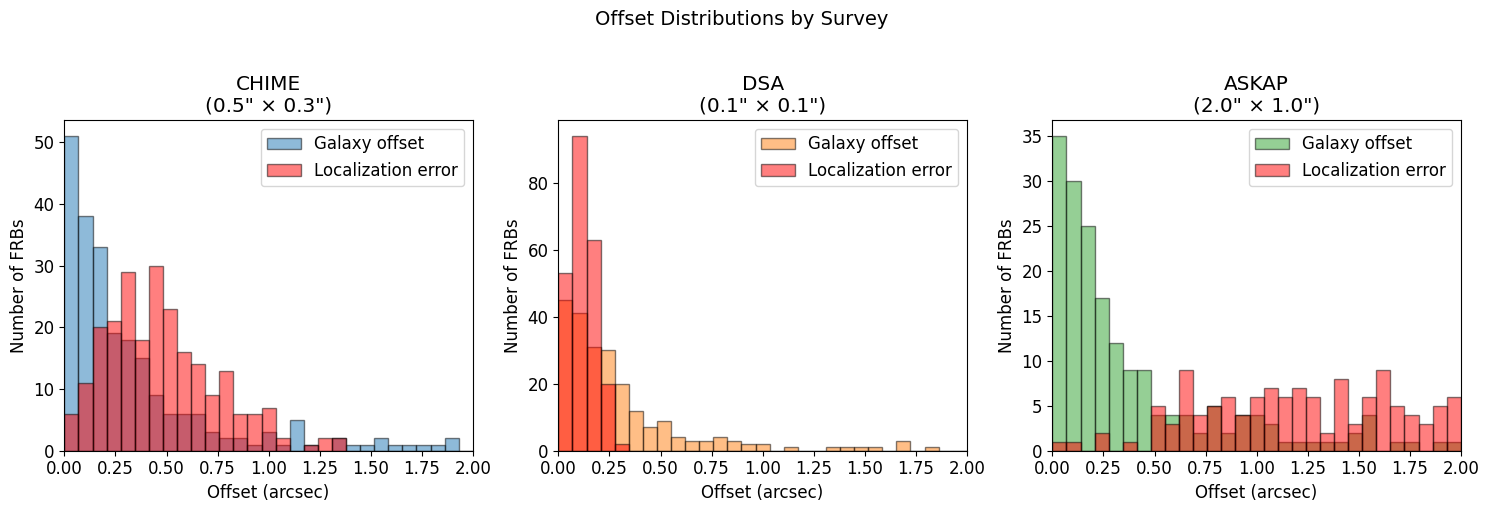

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
colors = ['#1f77b4', '#ff7f0e', '#2ca02c']

for ax, (survey, color) in zip(axes, zip(['CHIME', 'DSA', 'ASKAP'], colors)):
    assign = assignments_surveys[survey]
    
    # Plot both offsets
    bins = np.linspace(0, 2.0, 30)
    ax.hist(assign['gal_off'], bins=bins, alpha=0.5, label='Galaxy offset', 
            color=color, edgecolor='black')
    ax.hist(assign['loc_off'], bins=bins, alpha=0.5, label='Localization error', 
            color='red', edgecolor='black')
    
    ax.set_xlabel('Offset (arcsec)')
    ax.set_ylabel('Number of FRBs')
    ax.set_title(f'{survey}\n'
                 f'({localizations[survey][0]:.1f}" × {localizations[survey][1]:.1f}")')
    ax.legend()
    ax.set_xlim(0, 2.0)

plt.suptitle('Offset Distributions by Survey', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Step 7: Effect of Scale Parameter

The `scale` parameter controls how concentrated FRBs are near galaxy centers. 
- Smaller scale → more concentrated
- Larger scale → more spread out

In [14]:
# Compare different scale parameters
scales = [1.0, 2.0, 3.0]
assignments_scale = {}

for scale in scales:
    print(f"Assigning with scale={scale}...")
    assignments_scale[scale] = assign_frbs_to_hosts(
        frb_df=frbs_surveys['CHIME'][:200],  # Use subset for speed
        galaxy_catalog=galaxies,
        localization=(0.5, 0.3, 45.),
        scale=scale,
        mag_range=(17., 28.),
        seed=42
    )

Assigning with scale=1.0...
Assigning 157 FRBs to hosts (filtered from 200)
Iteration 1: 157 FRBs remaining
  Brightest unassigned FRB: m_r = 17.22 deg
  Max magnitude separation: 0.0001 deg deg
Assignment complete after 1 iterations
Generating FRB positions within galaxies...
Applying localization error...
Assigning with scale=2.0...
Assigning 157 FRBs to hosts (filtered from 200)
Iteration 1: 157 FRBs remaining
  Brightest unassigned FRB: m_r = 17.22 deg
  Max magnitude separation: 0.0001 deg deg
Assignment complete after 1 iterations
Generating FRB positions within galaxies...
Applying localization error...
Assigning with scale=3.0...
Assigning 157 FRBs to hosts (filtered from 200)
Iteration 1: 157 FRBs remaining
  Brightest unassigned FRB: m_r = 17.22 deg
  Max magnitude separation: 0.0001 deg deg
Assignment complete after 1 iterations
Generating FRB positions within galaxies...
Applying localization error...


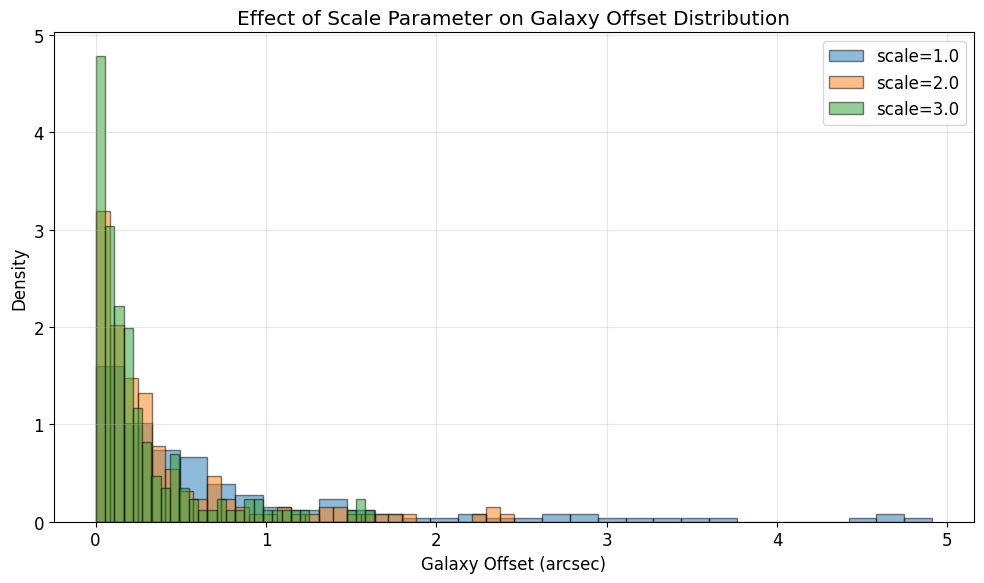


Median galaxy offsets:
  scale=1.0: 0.407"
  scale=2.0: 0.204"
  scale=3.0: 0.136"


In [15]:
fig, ax = plt.subplots(figsize=(10, 6))

colors = ['#1f77b4', '#ff7f0e', '#2ca02c']
for scale, color in zip(scales, colors):
    assign = assignments_scale[scale]
    ax.hist(assign['gal_off'], bins=30, alpha=0.5, label=f'scale={scale}', 
            color=color, edgecolor='black', density=True)

ax.set_xlabel('Galaxy Offset (arcsec)')
ax.set_ylabel('Density')
ax.set_title('Effect of Scale Parameter on Galaxy Offset Distribution')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Print statistics
print("\nMedian galaxy offsets:")
for scale in scales:
    median_off = assignments_scale[scale]['gal_off'].median()
    print(f"  scale={scale}: {median_off:.3f}\"")

## Step 8: Magnitude Matching Verification

The assignment algorithm matches FRBs to galaxies by magnitude. Let's verify that brighter FRBs are indeed assigned to brighter galaxies.

In [26]:
# Get original FRB magnitudes (before assignment)
# Match by FRB_ID
frb_mags = []
host_mags = []

ss = 0
for _, row in assignments.iterrows():
    #print(ss)
    frb_mag = frbs.iloc[int(row['FRB_ID'])]['m_r']
    frb_mags.append(frb_mag)
    host_mags.append(row['mag'])
    ss += 1

frb_mags = np.array(frb_mags)
host_mags = np.array(host_mags)

# Calculate correlation
correlation = np.corrcoef(frb_mags, host_mags)[0, 1]
print(f"Correlation between FRB m_r and host m_r: {correlation:.3f}")
print("(Should be close to 1.0, indicating successful magnitude matching)")

Correlation between FRB m_r and host m_r: 1.000
(Should be close to 1.0, indicating successful magnitude matching)


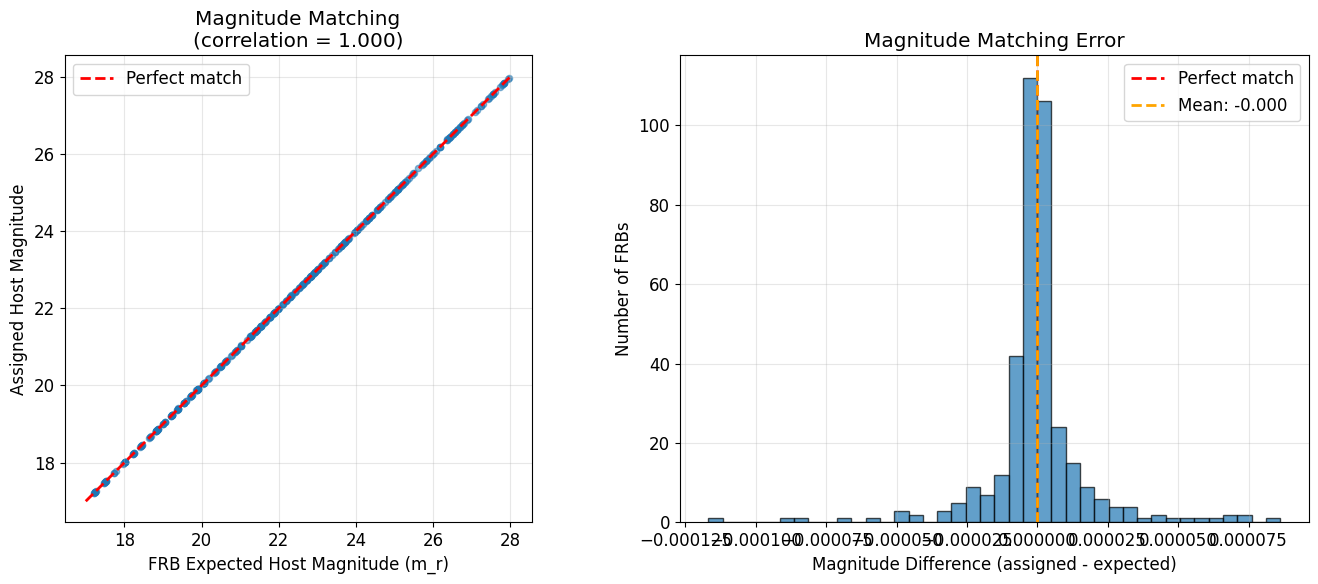


Magnitude matching statistics:
  Mean difference:   -0.000 mag
  Median difference: -0.000 mag
  Std deviation:     0.000 mag


In [27]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Scatter plot
ax = axes[0]
ax.scatter(frb_mags, host_mags, alpha=0.5, s=20)
ax.plot([17, 28], [17, 28], 'r--', linewidth=2, label='Perfect match')
ax.set_xlabel('FRB Expected Host Magnitude (m_r)')
ax.set_ylabel('Assigned Host Magnitude')
ax.set_title(f'Magnitude Matching\n(correlation = {correlation:.3f})')
ax.legend()
ax.grid(alpha=0.3)
ax.set_aspect('equal')

# Difference histogram
ax = axes[1]
mag_diff = host_mags - frb_mags
ax.hist(mag_diff, bins=40, alpha=0.7, edgecolor='black')
ax.axvline(0, color='red', linestyle='--', linewidth=2, label='Perfect match')
ax.axvline(mag_diff.mean(), color='orange', linestyle='--', linewidth=2, 
           label=f'Mean: {mag_diff.mean():.3f}')
ax.set_xlabel('Magnitude Difference (assigned - expected)')
ax.set_ylabel('Number of FRBs')
ax.set_title('Magnitude Matching Error')
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

print(f"\nMagnitude matching statistics:")
print(f"  Mean difference:   {mag_diff.mean():.3f} mag")
print(f"  Median difference: {np.median(mag_diff):.3f} mag")
print(f"  Std deviation:     {mag_diff.std():.3f} mag")

## Step 9: Saving Results

Save the assignment results for later use or PATH analysis.

In [28]:
# Save to CSV
# assignments.to_csv('frb_host_assignments.csv', index=False)
print("Example: Save to CSV")
print("  assignments.to_csv('frb_host_assignments.csv', index=False)")

# Save to Parquet (more efficient for large datasets)
# assignments.to_parquet('frb_host_assignments.parquet', index=False)
print("\nExample: Save to Parquet")
print("  assignments.to_parquet('frb_host_assignments.parquet', index=False)")

print("\nOutput columns:")
for col in assignments.columns:
    print(f"  - {col}")

Example: Save to CSV
  assignments.to_csv('frb_host_assignments.csv', index=False)

Example: Save to Parquet
  assignments.to_parquet('frb_host_assignments.parquet', index=False)

Output columns:
  - ra
  - dec
  - true_ra
  - true_dec
  - gal_ID
  - gal_off
  - mag
  - half_light
  - loc_off
  - FRB_ID
  - a
  - b
  - PA


## Summary

This notebook demonstrated the complete workflow for assigning FRBs to host galaxies:

1. **Generate FRBs**: Create realistic FRB populations with `generate_frbs()`
2. **Load catalog**: Use real galaxy catalog (HSC/DECaLs/HECATE) if available, otherwise mock
3. **Assign hosts**: Use `assign_frbs_to_hosts()` with appropriate localization
4. **Analyze results**: Examine offset distributions and host properties
5. **Compare surveys**: Test different localization scenarios
6. **Verify matching**: Confirm magnitude-based assignment worked correctly

### Using Real Data

This notebook automatically uses the real **combined HSC/DECaLs/HECATE galaxy catalog** if available:
- Set environment variable: `export FRB_APATH=/path/to/data/Catalogs`
- Catalog file: `combined_HSC_DECaLs_HECATE_galaxies_hecatecut.parquet`
- Contains **~2.3 million galaxies** from real surveys
- Falls back to mock catalog if not available

### Key Parameters

- **localization**: `(a, b, PA)` - Error ellipse defining localization precision
- **mag_range**: `(min, max)` - Magnitude range for FRB filtering
- **scale**: Controls galaxy offset concentration (default: 2.0)
- **seed**: Random seed for reproducibility

### Output

The assignments DataFrame contains:
- Observed and true FRB coordinates
- Host galaxy properties
- Offset statistics
- Localization parameters

### Next Steps

- Run PATH analysis on the assigned FRBs
- Compare assigned hosts with PATH posteriors
- Study systematic biases in host association
- Test different survey strategies
- Apply to real FRB observations